In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sns.set()

# Ejercicio de clasificación usando kNN

Sos un data scientist que trabaja para una empresa de publicidad que lanzo una campaña de publicidad en una red social. 
Se registró cada usuario al que se le mostró la publicidad, y se pudo obtener datos de la persona tales como 
`genero`, `edad` y `salario estimado`. Además, se registró si el usuario luego compró el producto que la publicidad 
hacía referencia. Los datos están en `Social_Network_Ads.csv`. Se busca poder predecir dado un usuario con datos 
socioeconómicos si va a comprar o no el producto.

1. Realice un estudio de variables y de limpieza de datos. Analice las clases, están balanceadas, o no? ¿Qué clase 
nos parece más importante de las dos?
2. Separe el dataset en entrenamiento y validación.
3. Elija diferentes modelos de clasificación (al menos uno de regresión logística y uno de KNN). Elija las variables 
de entrada basándonos en el análisis del punto 1.
4. Compárelos con dos o más metrica de evaluación. ¿Cuál fue el mejor modelo? ¿Todas las métricas coincidieron o 
métricas diferentes evaluan como mejor a diferentes modelos? Discuta los resultados.
5. Para la regresión logística, cree una curva ROC para evaluar el modelo para ver la calidad del modelo, sin depender 
del valor umbral. Elija un valor umbral que considere más óptimo y vuelva a clasificar usando ese valor. ¿Cómo 
cambiaron las métricas usadas en el punto 4 con este valor umbral?
6. Utilizando alguna técnica de busqueda de hiper-parámetros, busque para el clasificador kNN los mejores parámetros. 
Se recomienda usar `n_neighbors`, `weights` y 'p', dejando el parámetro de distancia fijo como `'minkowski'`.


In [68]:
ads_df = pd.read_csv("./datasets/Social_Network_Ads.csv")

Como siempre, vemos un poco nuestros datos

In [69]:
ads_df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


In [70]:
ads_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User ID          400 non-null    int64  
 1   Gender           400 non-null    object 
 2   Age              400 non-null    float64
 3   EstimatedSalary  400 non-null    float64
 4   Purchased        400 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 15.8+ KB


In [71]:
ads_df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


Veamos la clase (default):

In [72]:
ads_df.Purchased.value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [73]:
ads_df.Purchased.value_counts(normalize=True)

Purchased
0    0.6425
1    0.3575
Name: proportion, dtype: float64

No hay mucho desbalance en las clases. Es mas importante la clase de Purchased = 1, porque nos interesa saber si la gente compra en base a la publicidad que mostramos

Obsérvese que tenemos una gran desproporción de clases. Tenemos 3.3% de observaciónes de personas que no pagaron. 

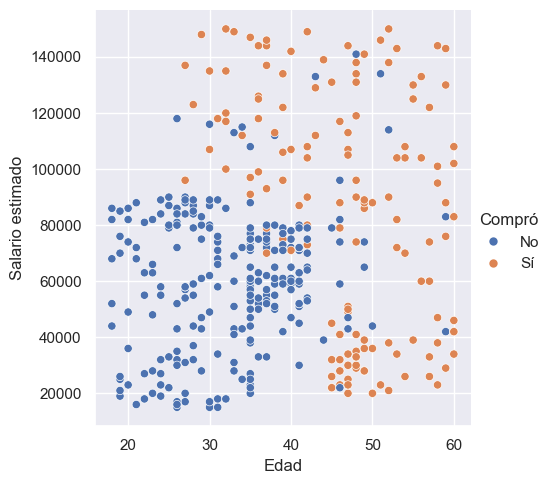

In [74]:
ads_plot = ads_df.copy()
ads_plot["Compró"] = ads_plot["Purchased"].map({0: "No", 1: "Sí"})

g = sns.relplot(data=ads_plot, x="Age", y="EstimatedSalary", hue="Compró",
                kind="scatter", legend=True)
plt.xlabel("Edad")
plt.ylabel("Salario estimado");

In [75]:
ads_df["Gender"] = ads_df["Gender"].apply(lambda x: 1 if x == "Male" else 0)

### Modelo de regresión logística

Para tener un punto de comparación, usemos el modelo de regresión logística realizado en Inteligencia Artificial.

In [76]:
from sklearn.linear_model import LogisticRegression

In [77]:
# como siempre vamos separando nuestras variables predictoras de la variable a predecir
X = ads_df.loc[:, ["Age", "EstimatedSalary", "Gender"]].values
y = ads_df.loc[:, "Purchased"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0, stratify=y)

In [78]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()

X_train = sc_X.fit_transform(X_train) 
X_test = sc_X.transform(X_test)

In [79]:
model_logistic = LogisticRegression(random_state = 0, class_weight="balanced")
model_logistic.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=0)

In [80]:
y_pred = model_logistic.predict(X_test)

# Creamos la matriz de confusión
cm_logistic = confusion_matrix(y_test, y_pred)

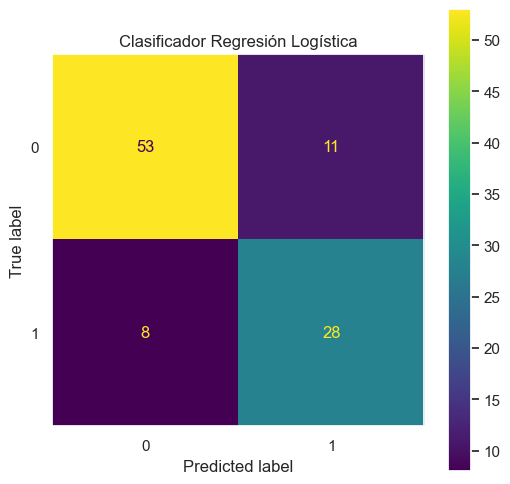

In [81]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic,
                              display_labels=model_logistic.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador Regresión Logística");

In [82]:
# Midamos la sensibilidad y especificidad
print("Clasificador Regresión Logística")
P = np.sum(cm_logistic[1, :])
N = np.sum(cm_logistic[0, :])
TP = cm_logistic[1, 1]
TN = cm_logistic[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0)}")

Clasificador Regresión Logística
Sensibilidad: 0.7777777777777778
Especificidad: 0.828125
Exactitud balanceada: 0.8029513888888888
Precision: 0.717948717948718
Recuperación: 0.7777777777777778
F1-score: 0.7466666666666667


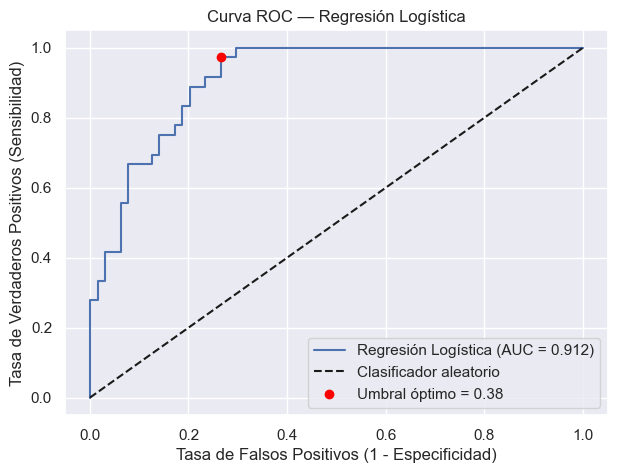

In [83]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model_logistic.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Umbral óptimo: maximiza índice de Youden (TPR - FPR)
youden_idx = np.argmax(tpr - fpr)
umbral_optimo = thresholds[youden_idx]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, label=f"Regresión Logística (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
ax.scatter(fpr[youden_idx], tpr[youden_idx], color="red", zorder=5,
           label=f"Umbral óptimo = {umbral_optimo:.2f}")
ax.set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title("Curva ROC — Regresión Logística")
ax.legend()
plt.show()

In [84]:
# sklearn.predict() clasifica como 1 cuando prob >= 0.5 (hardcodeado internamente)
umbral_default = 0.5
print(f"Umbral por defecto (sklearn predict): {umbral_default}")
print(f"Umbral óptimo (Youden): {umbral_optimo:.4f}")

# Reclasificar con umbral óptimo
y_pred_opt = (y_prob >= umbral_optimo).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)

P = np.sum(cm_opt[1, :])
N = np.sum(cm_opt[0, :])
TP = cm_opt[1, 1]
TN = cm_opt[0, 0]
TPR = TP / P
TNR = TN / N

print(f"\nMétricas con umbral óptimo ({umbral_optimo:.2f}):")
print(f"Sensibilidad:         {TPR:.4f}")
print(f"Especificidad:        {TNR:.4f}")
print(f"Exactitud balanceada: {(TPR + TNR) / 2:.4f}")
print(f"Precision:            {precision_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"Recuperación:         {recall_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"F1-score:             {f1_score(y_test, y_pred_opt, zero_division=0):.4f}")

Umbral por defecto (sklearn predict): 0.5
Umbral óptimo (Youden): 0.3842

Métricas con umbral óptimo (0.38):
Sensibilidad:         0.9722
Especificidad:        0.7344
Exactitud balanceada: 0.8533
Precision:            0.6731
Recuperación:         0.9722
F1-score:             0.7955


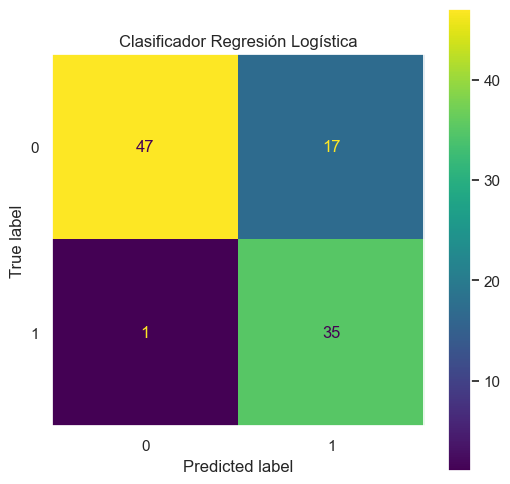

In [85]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt,
                              display_labels=model_logistic.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador Regresión Logística");

### Comparación de métricas: umbral por defecto (0.50) vs umbral óptimo (0.38)

| Métrica              | Umbral 0.50 | Umbral 0.38 | Δ       |
|----------------------|-------------|-------------|---------|
| Sensibilidad         | 0.7778      | 0.9722      | +0.1944 |
| Especificidad        | 0.8281      | 0.7344      | −0.0937 |
| Exactitud balanceada | 0.8030      | 0.8533      | +0.0503 |
| Precisión            | 0.7179      | 0.6731      | −0.0448 |
| Recuperación         | 0.7778      | 0.9722      | +0.1944 |
| F1-score             | 0.7467      | 0.7955      | +0.0488 |

Al bajar el umbral de 0.50 a 0.38, el modelo es más "generoso" para predecir la clase positiva (Purchased=1). Esto produce el clásico trade-off precisión/recall:

- **Sensibilidad y Recuperación suben fuertemente (+19%)**: el modelo detecta muchos más compradores reales (menos falsos negativos). Esto es deseable en publicidad, donde perder un comprador potencial tiene costo.
- **Especificidad y Precisión bajan moderadamente**: se generan más falsos positivos (usuarios clasificados como compradores que no lo son), lo que aumenta el costo de mostrar publicidad innecesaria.
- **F1-score y exactitud balanceada mejoran**: el balance general es mejor con el umbral 0.38, lo que confirma que 0.50 no era óptimo para este dataset.

## Clasificador KNN

Vamos a usar el clasificador KNN de [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html). Para este ejemplo, vamos a usar el mismo dataset de la regresión logistica.

In [86]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [87]:
def objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 20)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    p = trial.suggest_int("p", 1, 100)

    classifier = KNeighborsClassifier(
        n_neighbors=n_neighbors, weights=weights, p=p, metric="minkowski"
    )
    score = cross_val_score(classifier, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    return score.mean()

In [88]:
def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get("winner", None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value) * 100
            print(f"Trial {frozen_trial.number} achieved value: {frozen_trial.value:.4f} "
                  f"({improvement_percent:.4f}% improvement)")
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value:.4f}")

In [89]:
optuna.logging.set_verbosity(optuna.logging.ERROR)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200, callbacks=[champion_callback])

best_params = study.best_params
print(f"\nMejores hiperparámetros: {best_params}")
print(f"Mejor F1 (CV): {study.best_value:.4f}")

Initial trial 0 achieved value: 0.8703
Trial 7 achieved value: 0.8837 (1.5205% improvement)

Mejores hiperparámetros: {'n_neighbors': 7, 'weights': 'distance', 'p': 24}
Mejor F1 (CV): 0.8837


In [90]:
# Entrenamos con los mejores hiperparámetros encontrados por Optuna
from sklearn.neighbors import KNeighborsClassifier

classifier_knn = KNeighborsClassifier(**best_params, metric="minkowski")
classifier_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7, p=24, weights='distance')

In [91]:
#Evaluamos
y_pred  = classifier_knn.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred)

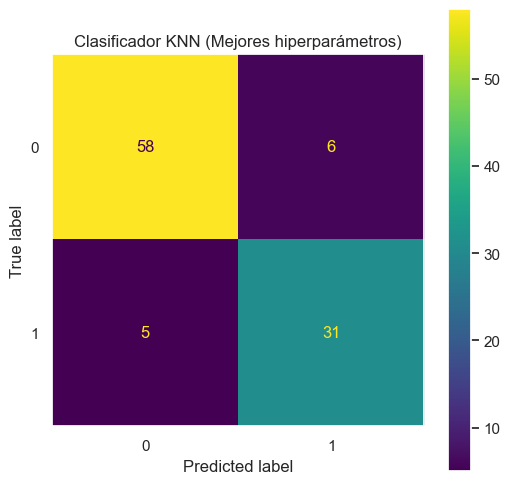

In [92]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                              display_labels=classifier_knn.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador KNN (Mejores hiperparámetros)");

In [93]:
# Midamos la sensibilidad y especificidad
print("Clasificador KNN (Mejores hiperparámetros)")
P = np.sum(cm_knn[1, :])
N = np.sum(cm_knn[0, :])
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0)}")

Clasificador KNN (Mejores hiperparámetros)
Sensibilidad: 0.8611111111111112
Especificidad: 0.90625
Exactitud balanceada: 0.8836805555555556
Precision: 0.8378378378378378
Recuperación: 0.8611111111111112
F1-score: 0.8493150684931506


## Comparación final de modelos

| Métrica              | RegLog (umbral 0.50) | RegLog (umbral 0.38) | KNN Optuna (k=7) |
|----------------------|---------------------|---------------------|------------------|
| Sensibilidad         | 0.7778              | **0.9722**          | 0.8611           |
| Especificidad        | 0.8281              | 0.7344              | **0.9063**       |
| Exactitud balanceada | 0.8030              | 0.8533              | **0.8837**       |
| Precisión            | 0.7179              | 0.6731              | **0.8378**       |
| Recuperación         | 0.7778              | **0.9722**          | 0.8611           |
| F1-score             | 0.7467              | 0.7955              | **0.8493**       |

**KNN con Optuna** gana en la mayoría de las métricas (especificidad, exactitud balanceada, precisión y F1). **Regresión logística con umbral 0.38** gana en sensibilidad/recuperación, detectando más compradores reales a costa de más falsos positivos.

La elección del modelo final depende del negocio: si el objetivo es maximizar la detección de compradores (recall), conviene RegLog con umbral 0.38. Si se busca un balance entre precisión y recall con menor tasa de falsos positivos, KNN con Optuna es la mejor opción.

In [94]:
# Entrenamos con los mejores hiperparámetros encontrados por Optuna
from sklearn.svm import SVC

In [95]:
def objective(trial):
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly"])
    C = trial.suggest_float("C", 1e-1, 1e1, log=True)

    cw_strategy = trial.suggest_categorical("cw_strategy", ["balanced", "weighted"])
    if cw_strategy == "balanced":
        class_weight = "balanced"
    else:
        w1 = trial.suggest_float("w1", 1.5, 5.0)
        class_weight = {0: 1.0, 1: w1}

    params = {"kernel": kernel, "C": C, "class_weight": class_weight, "random_state": 0}
    if kernel == "rbf":
        params["gamma"] = trial.suggest_float("gamma", 1e-2, 1e1, log=True)
    else:  # poly
        params["degree"] = trial.suggest_int("degree", 2, 4)
        params["gamma"] = trial.suggest_float("gamma_poly", 1e-2, 1e1, log=True)

    model = SVC(**{k.replace("gamma_poly", "gamma"): v for k, v in params.items()})
    scores = cross_val_score(model, X_train, y_train, cv=3,
                             scoring="f1", n_jobs=-1)
    return scores.mean()

In [96]:
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=0),
    pruner=MedianPruner(n_warmup_steps=5),
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Mejor F1 (CV): {study.best_value:.4f}")
print(f"Mejores hiperparámetros: {study.best_params}")

bp = dict(study.best_params)
if bp.pop("cw_strategy") == "balanced":
    class_weight = "balanced"
else:
    class_weight = {0: 1.0, 1: bp.pop("w1")}
if "gamma_poly" in bp:
    bp["gamma"] = bp.pop("gamma_poly")
classifier_svc = SVC(**bp, class_weight=class_weight, random_state=0)
classifier_svc.fit(X_train, y_train)

  0%|          | 0/30 [00:00<?, ?it/s]

Mejor F1 (CV): 0.8942
Mejores hiperparámetros: {'kernel': 'rbf', 'C': 0.24726618219776433, 'cw_strategy': 'weighted', 'w1': 1.8398544652757145, 'gamma': 3.264635677523522}


SVC(C=0.24726618219776433, class_weight={0: 1.0, 1: 1.8398544652757145},
    gamma=3.264635677523522, random_state=0)

In [97]:
#Evaluamos
y_pred  = classifier_svc.predict(X_test)

cm_svc = confusion_matrix(y_test, y_pred)

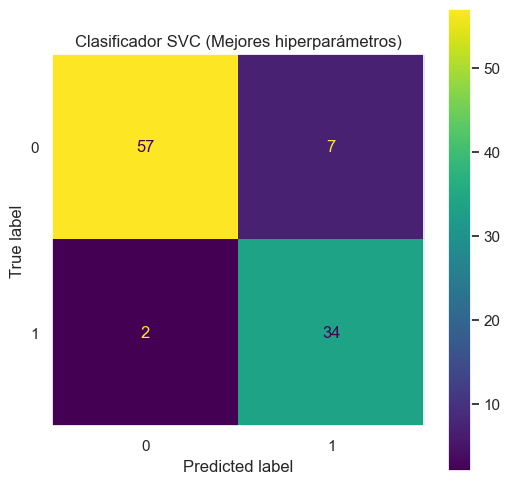

In [98]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svc,
                              display_labels=classifier_svc.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Clasificador SVC (Mejores hiperparámetros)");

In [99]:
# Midamos la sensibilidad y especificidad
print("Clasificador SVC (Mejores hiperparámetros)")
P = np.sum(cm_svc[1, :])
N = np.sum(cm_svc[0, :])
TP = cm_svc[1, 1]
TN = cm_svc[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0)}")

Clasificador SVC (Mejores hiperparámetros)
Sensibilidad: 0.9444444444444444
Especificidad: 0.890625
Exactitud balanceada: 0.9175347222222222
Precision: 0.8292682926829268
Recuperación: 0.9444444444444444
F1-score: 0.8831168831168831
